# DAY 155 - Model Evaluation Metrics.
@A.IPYNB

# Beyond Accuracy: The Art of Model Evaluation

### The Golden Rule
**Loss Functions** (e.g., CrossEntropy, MSE) are for the **Optimizer** (Gradient Descent).
**Evaluation Metrics** (e.g., F1-Score, mAP) are for the **Human** (Business Logic).

### Why "Accuracy" is a Trap
Imagine a fraud detection dataset where only 1% of transactions are fraudulent.
If you build a model that says **"Not Fraud"** for 100% of cases, it has **99% Accuracy**.
It is also **100% Useless**.

To evaluate Deep Learning models properly, we need metrics that understand:
1.  **Imbalance:** (Precision/Recall/F1)
2.  **Confidence:** (Log Loss/Calibration)
3.  **Spatial Overlap:** (IoU for Computer Vision)

In [5]:
# @title 1. The Accuracy Paradox
# I am creating a highly imbalanced dataset (98% Class 0, 2% Class 1)
# and prove why Accuracy fails.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Generation of Imbalanced Data
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.98, 0.02], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Training a "Dumb" Model (Always predicts majority class)
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)
preds = dummy_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, preds):.4f} (Looks amazing!)")
print(f"F1-Score: {f1_score(y_test, preds):.4f} (The truth revealed)")

# The F1 score is 0.0 because the model failed to find a single fraud case.

Accuracy: 0.9800 (Looks amazing!)
F1-Score: 0.0000 (The truth revealed)


### The Holy Trinity of Classification

**1. Precision**
"When the model says it's a Dog, is it actually a Dog?"
* *Use case:* Spam filters (False Positives are annoying).

$$Precision = \frac{TP}{TP + FP}$$

**2. Recall (Sensitivity)**
"Of all the Dogs in the world, how many did the model find?"
* *Use case:* Cancer detection (False Negatives are deadly).

$$Recall = \frac{TP}{TP + FN}$$

**3. F1-Score**
The Harmonic Mean of Precision and Recall. It forces the model to be good at both.

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

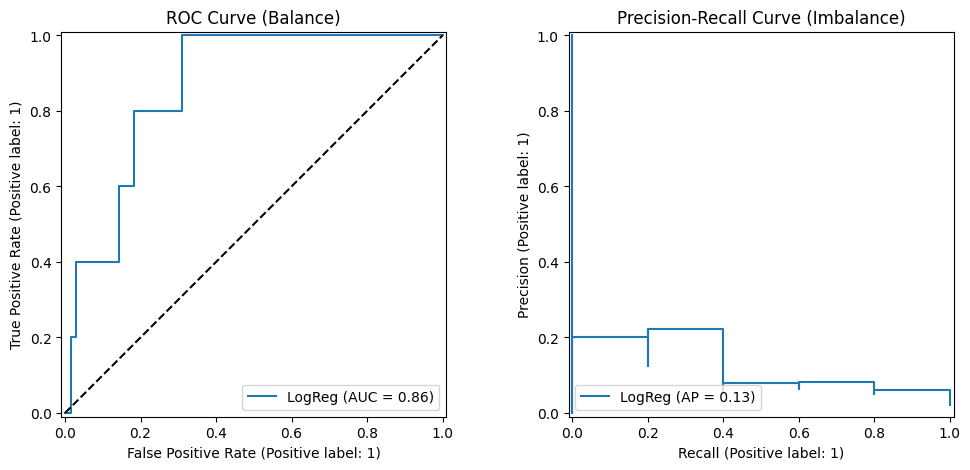

In [6]:
# @title 2. ROC and Precision-Recall Curves
# I'll train a real Logistic Regression model to visualize its trade-offs.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

model = LogisticRegression()
model.fit(X_train, y_train)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. ROC Curve (Receiver Operating Characteristic)
# Good for balanced datasets.
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax1, name="LogReg")
ax1.set_title("ROC Curve (Balance)")
ax1.plot([0, 1], [0, 1], "k--")

# 2. Precision-Recall Curve
# BETTER for imbalanced datasets (Fraud, Rare Disease).
PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax2, name="LogReg")
ax2.set_title("Precision-Recall Curve (Imbalance)")

plt.show()

### Predicting Values (Regression)

**1. MSE (Mean Squared Error)**
* Squaring the error ($e^2$) penalizes **outliers** heavily.
* *Use case:* When being wrong by a large amount is unacceptable (e.g., self-driving car steering).

$$MSE = \frac{1}{n} \sum (y - \hat{y})^2$$

**2. MAE (Mean Absolute Error)**
* Takes absolute value ($|e|$). Treats all errors linearly.
* *Use case:* Financial forecasting (robust to market spikes).

$$MAE = \frac{1}{n} \sum |y - \hat{y}|$$

In [7]:
# @title 3. MSE vs MAE Visualizer
# See how one outlier changes the metric.

y_true = np.array([100, 102, 98, 105, 100])
y_pred_good = np.array([101, 101, 99, 104, 101]) # Consistent small errors
y_pred_outlier = np.array([100, 102, 98, 105, 150]) # Perfect except one massive error

from sklearn.metrics import mean_squared_error, mean_absolute_error

print("--- Scenario A: Good Predictions ---")
print(f"MSE: {mean_squared_error(y_true, y_pred_good):.2f}")
print(f"MAE: {mean_absolute_error(y_true, y_pred_good):.2f}")

print("\n--- Scenario B: One Outlier ---")
print(f"MSE: {mean_squared_error(y_true, y_pred_outlier):.2f} (Exploded by 250x!)")
print(f"MAE: {mean_absolute_error(y_true, y_pred_outlier):.2f} (Only increased by 10x)")

--- Scenario A: Good Predictions ---
MSE: 1.00
MAE: 1.00

--- Scenario B: One Outlier ---
MSE: 500.00 (Exploded by 250x!)
MAE: 10.00 (Only increased by 10x)


### Intersection over Union (IoU)
In Object Detection (YOLO, Faster R-CNN), "Accuracy" doesn't exist. We predict boxes.
How do we know if a predicted box is "correct"?

We measure the overlap area between the **Predicted Box** and the **Ground Truth Box**.

$$IoU = \frac{\text{Area of Overlap}}{\text{Area of Union}}$$

* **IoU > 0.5:** Often considered a "Hit" (True Positive).
* **IoU > 0.9:** Almost perfect alignment.

Perfect Match IoU: 1.0000
Partial Match IoU: 0.1429


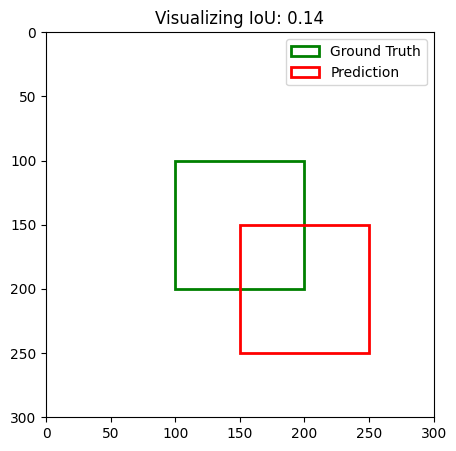

In [8]:
# @title 4. Calculating IoU (Intersection over Union)
import torch

def calculate_iou(box1, box2):
    """
    Calculates IoU for two boxes [x1, y1, x2, y2]
    """
    xi1 = max(box1[0], box2[0])
    yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2])
    yi2 = min(box1[3], box2[3])

    inter_width = max(0, xi2 - xi1)
    inter_height = max(0, yi2 - yi1)
    inter_area = inter_width * inter_height

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area

    # IoU
    return inter_area / union_area

truth = [100, 100, 200, 200]
perfect_pred = [100, 100, 200, 200]
bad_pred = [150, 150, 250, 250] # Partially overlapping

print(f"Perfect Match IoU: {calculate_iou(truth, perfect_pred):.4f}")
print(f"Partial Match IoU: {calculate_iou(truth, bad_pred):.4f}")

import matplotlib.patches as patches
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(0, 300); ax.set_ylim(300, 0)

rect1 = patches.Rectangle((truth[0], truth[1]), 100, 100, linewidth=2, edgecolor='g', facecolor='none', label='Ground Truth')
rect2 = patches.Rectangle((bad_pred[0], bad_pred[1]), 100, 100, linewidth=2, edgecolor='r', facecolor='none', label='Prediction')

ax.add_patch(rect1)
ax.add_patch(rect2)
plt.legend()
plt.title(f"Visualizing IoU: {calculate_iou(truth, bad_pred):.2f}")
plt.show()

### Summary Checklist for Evaluation

**1. Is your data balanced?**
* **Yes:** Use **Accuracy** and **ROC Curve**.
* **No:** Use **F1-Score** and **Precision-Recall Curve**.

**2. Are you predicting a number? (Regression)**
* **Care about outliers?** Use **MSE** (Mean Squared Error).
* **Want robustness?** Use **MAE** (Mean Absolute Error).

**3. Are you detecting objects?**
* Use **mAP (Mean Average Precision)**.
* This calculates Precision at different IoU thresholds (e.g., mAP@0.50).

**The Strategic Win**
Choosing the right metric allows you to align your Deep Learning model with actual business goals, ensuring you aren't optimizing for vanity numbers that fail in production.